# Simple Linear Regression

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score , mean_squared_error
import seaborn as sns
import matplotlib.pyplot as plt

## Task 1 : Simple data training and prediction

In [2]:
df = pd.read_csv("Datasets/student_scores.csv")
print(df.head())

# get indepanded & depanded data
x = df[["Hours"]]
y = df['Scores']

# split data in training & testing
X_train , X_test , y_train , y_test = train_test_split(x , y , test_size=0.2 , random_state = 42)

# initialized model
model = LinearRegression()

# fit data into model
model.fit(X_train , y_train)

# predict values
y_pre = model.predict(X_test)

# get r2_score
r2 = r2_score(y_test , y_pre)
print("r2_score : " , r2)

# print mean_squared_error
mse = mean_squared_error(y_test , y_pre)
print("mean_squared_error :",mse)

# print other thing
print("Coefficient :" , model.coef_)
print("Intercept :" , model.intercept_)

   Hours  Scores
0    2.5      21
1    5.1      47
2    3.2      27
3    8.5      75
4    3.5      30
r2_score :  0.9678055545167994
mean_squared_error : 18.943211722315272
Coefficient : [9.68207815]
Intercept : 2.826892353899737


## Task 2 : Optimization

   Hours  Scores
0    2.5      21
1    5.1      47
2    3.2      27
3    8.5      75
4    3.5      30
best r2 :  0.9842077430211454
best mse :  10.268915100500191


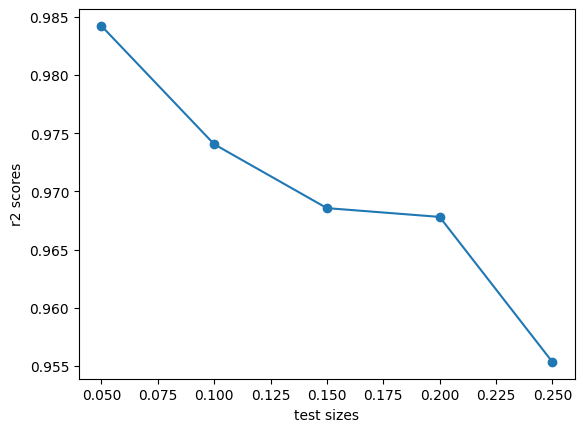

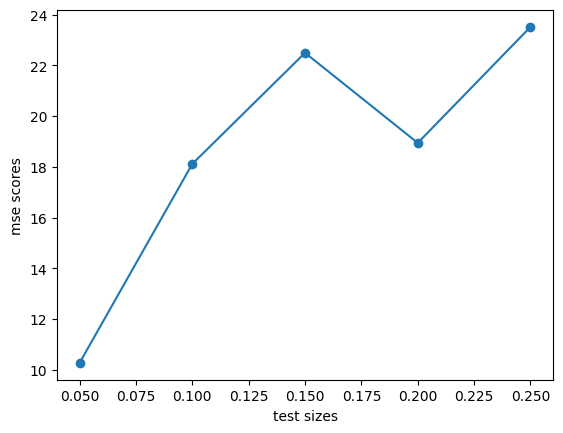

new data prediction
Hours : 2 --> prediction : 21.66
Hours : 4.5 --> prediction : 46.40
Hours : 6 --> prediction : 61.24
Hours : 8 --> prediction : 81.03
Hours : 9.5 --> prediction : 95.88


c:\Users\Admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [3]:
df = pd.read_csv("Datasets/student_scores.csv")
print(df.head())

x = df[['Hours']]
y = df['Scores']


test_sizes = [0.05 , 0.1 , 0.15 , 0.2 , 0.25]
all_r2 = []
all_mse = []
best_r2 = -1
best_mse = None
best_model = None

for i in test_sizes :
    X_train , X_test , y_train , y_test = train_test_split(x,y,test_size=i , random_state = 42)
    model = LinearRegression()

    model.fit(X_train , y_train)

    y_pre = model.predict(X_test)

    r2 = r2_score(y_test , y_pre)
    mse = mean_squared_error(y_test , y_pre)

    all_r2.append(r2)
    all_mse.append(mse)
    if r2 > best_r2 :
        best_r2 = r2
        best_mse = mse
        best_model = model

print("best r2 : " , best_r2)
print("best mse : " , best_mse)

plt.plot(test_sizes , all_r2 , marker='o')
plt.xlabel("test sizes")
plt.ylabel("r2 scores")
plt.show()

plt.plot( test_sizes , all_mse , marker='o')
plt.xlabel("test sizes")
plt.ylabel("mse scores")
plt.show()

# new unseen data
new_data = [ [2] , [4.5] , [6] , [8] , [9.5] ]

new_pre = best_model.predict(new_data)

print("new data prediction")
for h , p in zip(new_data , new_pre) :
    print(f"Hours : {h[0]} --> prediction : {p:.2f}")

# Multiple Linear Regression

## task 3 : simple data training and prediction for multiple linear regression

In [4]:
df = pd.read_csv("Datasets/insurance.csv")
print(df.head())

# get depanded & indepanded cols
x = df.drop("charges" , axis=1)
y = df['charges']

x = pd.get_dummies(x)

# split data for train & test
X_train , X_test , y_train , y_test = train_test_split(x , y , test_size = 0.2 , random_state = 42)

# initialized model
model = LinearRegression()

model.fit(X_train , y_train)

# predict values
y_pre = model.predict(X_test)

# r2_score
r2 = r2_score(y_test , y_pre)
print("r2 score :" , r2)
# mse
mse = mean_squared_error(y_test , y_pre)
print("mse :" , mse)

# show Cofficients
print("\n=========== cofficients ===========\n")
for name , cof in zip(x.columns , model.coef_) :
    print(f"{name} : {cof}")

print("\nintercept :" , model.intercept_)

# predict new data
new_data = [[30 , 25.0 , 2 , 0 , 1 , 1, 0 , 1 , 0 , 0 , 0]]
new_pre = model.predict(new_data)

print("\nCharge for new data : " , new_pre[0])

   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520
r2 score : 0.7835929767120723
mse : 33596915.85136147

=========== cofficients ===========

age : 256.97570583119426
bmi : 337.0925519487766
children : 425.27878352427854
sex_female : 9.295845820502652
sex_male : -9.295845820505125
smoker_no : -11825.564427880612
smoker_yes : 11825.564427880608
region_northeast : 459.58524424373064
region_northwest : 88.90791801592727
region_southeast : -198.27905232091678
region_southwest : -350.2141099387422

intercept : -574.5357125102109

Charge for new data :  5037.331798736202


c:\Users\Admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


## task 4 : optimization for multiple linear regression

   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520

--> X train data

   age    bmi  children  sex_female  sex_male  smoker_no  smoker_yes  \
0   19  27.90         0        True     False      False        True   
1   18  33.77         1       False      True       True       False   

   region_northeast  region_northwest  region_southeast  region_southwest  
0             False             False             False              True  
1             False             False              True             False  
best r2 : 0.8103852209381559
best mse : 29872585.362626754


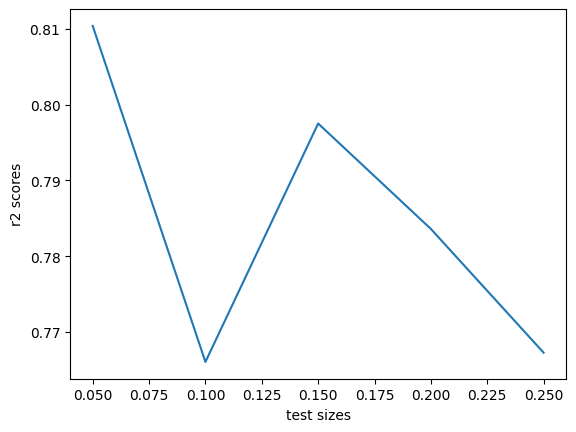

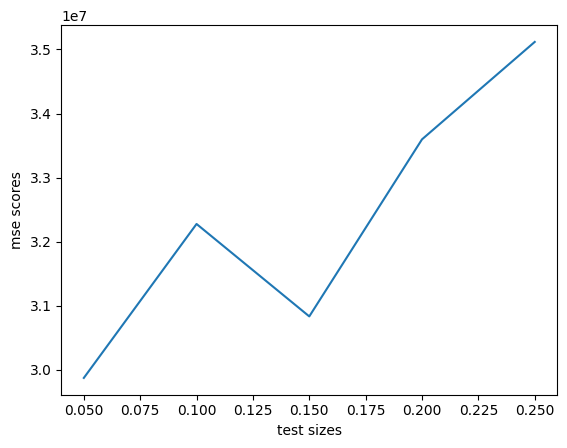


charge for user data :  6765.138628113185


c:\Users\Admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [5]:
df = pd.read_csv("Datasets/insurance.csv")
print(df.head())

x = df.drop("charges" , axis=1)
y = df['charges']

x = pd.get_dummies(x)
print("\n--> X train data\n")
print(x.head(2))

test_sizes = [0.05 , 0.1 , 0.15 , 0.2 , 0.25]
all_r2 = []
all_mse = []
best_r2 = -1
best_mse = None
best_model = None

for i in test_sizes :
    X_train , X_test , y_train , y_test = train_test_split(x , y ,test_size=i , random_state=42 )
    model = LinearRegression()
    model.fit(X_train , y_train)
    y_pre = model.predict(X_test)

    r2 = r2_score(y_test , y_pre)
    mse = mean_squared_error(y_test  , y_pre)

    if r2 > best_r2 :
        best_r2 = r2
        best_mse = mse
        best_model = model
    
    all_r2.append(r2)
    all_mse.append(mse)

print("best r2 :"  , best_r2)
print("best mse :"  , best_mse)

plt.plot( test_sizes , all_r2)
plt.xlabel("test sizes")
plt.ylabel("r2 scores")
plt.show()

plt.plot(test_sizes , all_mse)
plt.xlabel("test sizes")
plt.ylabel("mse scores")
plt.show()

# user predict : 
user_data = [[35 , 27.5 , 1 , 0 , 1 , 1 , 0 , 1, 0 , 0 , 0 ]]

user_prediction = model.predict(user_data)

print("\ncharge for user data : " , user_prediction[0])

# Polynomial Regression

## task 5 : normal polynomial regression

In [6]:
df = pd.read_csv('Datasets/insurance.csv')
print(df.head())

x = df.drop('charges' , axis=1)
y = df['charges']

x = pd.get_dummies(x , drop_first=True)

X_train , X_test , y_train , y_test = train_test_split(x , y , test_size=0.2 , random_state=42)

# polynimal obj
poly = PolynomialFeatures(degree=2)

# first time use only use fit_transform(no matter it is on X_train or X_test but first tranformation is on fit_transform) , then use any of these 
X_train_poly = poly.fit_transform(X_train) 
X_test_poly = poly.transform(X_test) 

# initailized model
model = LinearRegression()

model.fit(X_train_poly , y_train)

y_pre = model.predict(X_test_poly)

r2 = r2_score(y_test , y_pre)
print("r2 score :" , r2)

mse = mean_squared_error(y_test , y_pre)
print("mse :" , mse)

# check user data
user_data = [[35,27.5,1,1,0,0,0,1]]

user_data_poly = poly.transform(user_data)

user_pre = model.predict(user_data_poly)
print("\ncharges : " , user_pre[0])

   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520
r2 score : 0.8665830903164841
mse : 20712805.987918355

charges :  5600.076984094844


c:\Users\Admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


## Task 6 : Finding the best degree for polynomial regression with best test size

   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520

===== best model =====

best r2 :  0.8665830903164841
best mse :  20712805.987918355
best Degree :  2
best test size :  0.2


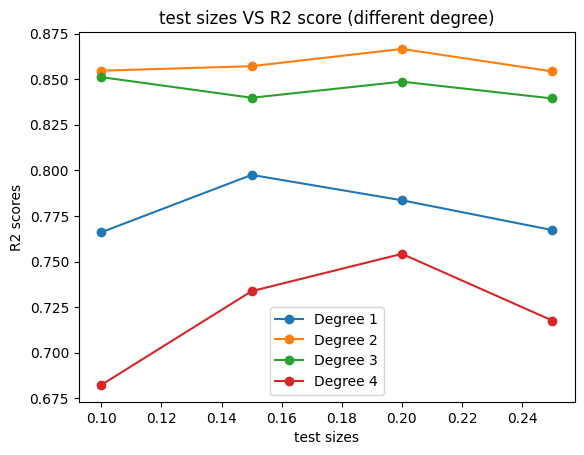

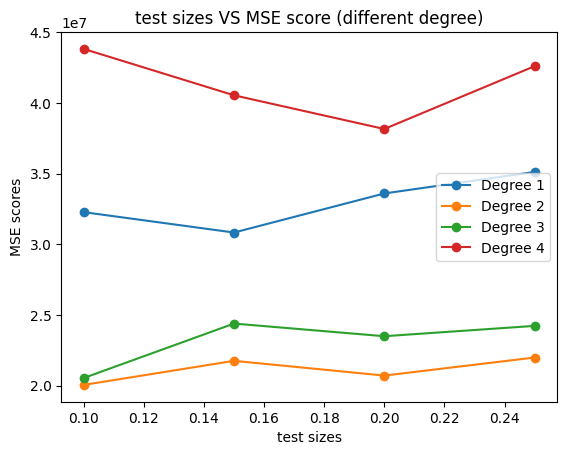

User define value's prediction : 27397.646786573714


In [7]:
df = pd.read_csv("Datasets/insurance.csv")
print(df.head())

x = df.drop('charges' , axis=1)
y = df['charges']

x = pd.get_dummies(x,drop_first=True)

test_sizes = [0.1 , 0.15 , 0.2 , 0.25]
degrees = [1,2,3,4]



result = []

best_r2 = -1
best_model = None
best_degree = None
best_test_size = None
best_mse = None
best_poly = None

for i in test_sizes :
    for j in degrees :
        X_train , X_test , y_train , y_test = train_test_split(x , y , test_size=i , random_state=42 )

        poly = PolynomialFeatures(degree=j)

        X_train_poly = poly.fit_transform(X_train)
        X_test_poly = poly.transform(X_test)

        model = LinearRegression()
        model.fit(X_train_poly , y_train)

        y_pre = model.predict(X_test_poly)

        r2 = r2_score(y_test , y_pre)
        mse = mean_squared_error(y_test , y_pre)

        if r2 > best_r2 :
            best_r2 = r2
            best_model = model
            best_degree = j
            best_test_size = i
            best_mse = mse
            best_poly = poly

        result.append((i,j,r2,mse))


print("\n===== best model =====\n")
print("best r2 : " , best_r2)
print("best mse : " , best_mse)
print("best Degree : " , best_degree)
print("best test size : " , best_test_size)


result_df = pd.DataFrame(result , columns=['Test size' , 'Degree' , 'R2' , 'MSE'])



# graph for test sizes VS R2 score
plt.figure()
for d in degrees :
    subset = result_df[ result_df['Degree'] == d ]
    plt.plot(subset['Test size'] , subset['R2'] , marker='o' , label=f'Degree {d}')
plt.xlabel("test sizes")
plt.ylabel("R2 scores")
plt.title("test sizes VS R2 score (different degree)")
plt.legend()
plt.show()

# graph for test sizes VS MSE score
plt.figure()
for d in degrees :
    subset = result_df[ result_df['Degree'] == d ]
    plt.plot(subset['Test size'] , subset['MSE'] , marker='o' , label=f'Degree {d}')
plt.xlabel("test sizes")
plt.ylabel("MSE scores")
plt.title("test sizes VS MSE score (different degree)")
plt.legend()
plt.show()


# user prediction
new_data = [[45,26.5,2,1,1,0,0,0]]
new_data_poly = best_poly.fit_transform(new_data)

new_pre = best_model.predict(new_data_poly)
print("User define value's prediction :",new_pre[0])

### Best Degree for polynomial

   age     sex    bmi  children smoker     region     charges
0   19  female  27.90         0    yes  southwest  16884.9240
1   18    male  33.77         1     no  southeast   1725.5523


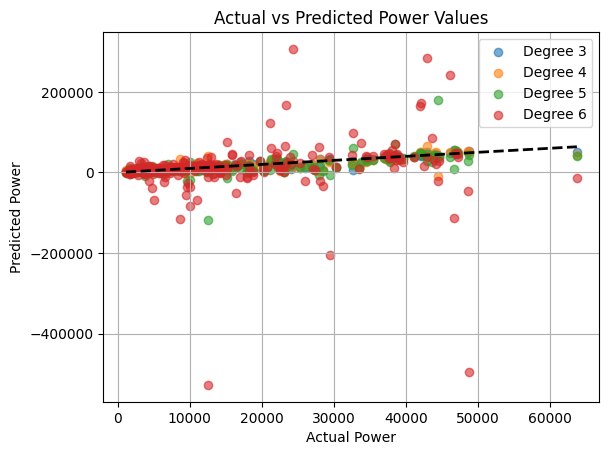

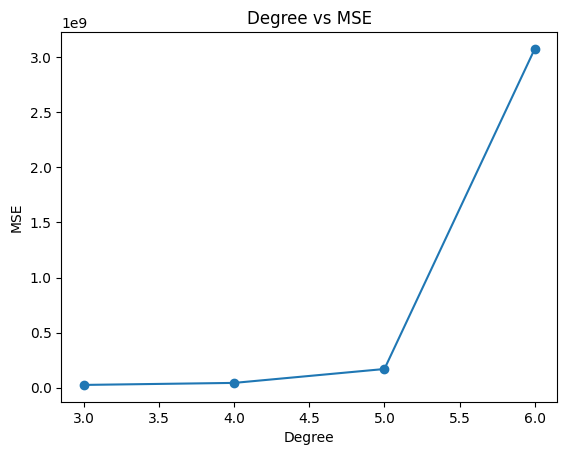

In [25]:
df = pd.read_csv("Datasets/insurance.csv")
print(df.head(2))

x = df.drop("charges" , axis=1)
y = df["charges"]

x = pd.get_dummies(x , drop_first=True)

X_train , X_test , y_train , y_test = train_test_split(x,y,test_size=0.25 , random_state=42)

degrees = [3,4,5,6]
best_r2 = 0
best_model = None
best_degree = None
best_poly = None
all_mse = []

for deg in degrees :
    poly = PolynomialFeatures(degree=deg)

    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)

    model = LinearRegression()
    model.fit(X_train_poly , y_train)
    y_pre = model.predict(X_test_poly)

    r2 = r2_score(y_test , y_pre)
    mse =   mean_squared_error(y_test , y_pre)
    all_mse.append(mse)

    if r2 > best_r2 :
        best_r2 = r2
        best_model = model
        best_poly = poly
        best_degree = deg
    
    plt.scatter(
        y_test,
        y_pre,
        label=f'Degree {deg}',
        alpha=0.6
    )
    
# Perfect Prediction Line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'k--',
    linewidth=2
)

plt.xlabel("Actual Power")
plt.ylabel("Predicted Power")
plt.title("Actual vs Predicted Power Values")
plt.legend()
plt.grid(True)
plt.show()

# MSE vs Degree

plt.plot(degrees , all_mse , marker='o')

plt.xlabel("Degree")
plt.ylabel("MSE")
plt.title("Degree vs MSE")
plt.show()


# KNN Regression

In [8]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score , classification_report , confusion_matrix , precision_score , recall_score

## Task 7 : simple data training and prediction for KNN regression

In [9]:
df = pd.read_csv("Datasets/diabetes.csv")
print(df.head())

# handle mission values --> in this dataset 0 means null value
cols_with_zero = ['Glucose' , 'BloodPressure' , 'SkinThickness' , 'Insulin' , 'BMI']
for col in cols_with_zero :
    df = df[ df[col] != 0 ]

# define X & Y
x = df.drop('Outcome' , axis=1)
y = df['Outcome']

# split into training & testing
X_train , X_test , y_train , y_test = train_test_split(x,y,test_size=.2 , random_state=42)

# define model
KNN = KNeighborsClassifier(n_neighbors = 3)

# fit data into model
KNN.fit(X_train , y_train)

# predict value 
y_pre = KNN.predict(X_test)

# find accuracy
acc = accuracy_score(y_test , y_pre)
print("Accuracy score :" , acc)

# find confusion matrix
cm = confusion_matrix(y_test , y_pre)
print("Condusion matrix : ",cm)
TN , FP , FN , TP = cm.ravel()

# find other things
print("Recall score :" , recall_score(y_test , y_pre))
print("precision score :" , precision_score(y_test , y_pre))


# all scores by manual formulas
acc_score = (TN + TP) / (TN + FP + FN + TP)
pre_score = (TP) / (FP + TP)
recall = (TP) / (FN + TP)
specificity = (TN) / (TN + FP)

print("\n---- manual formulas -----\n")
print("manual acc :",acc_score)
print("manual precision :",pre_score)
print("manual recall :",recall)
print("manual specificity :",specificity)

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  
Accuracy score : 0.6582278481012658
Condusion matrix :  [[40 12]
 [15 12]]
Recall score : 0.4444444444444444
precision score : 0.5

---- manual formulas -----

manual acc : 0.6582278481012658
manual precision : 0.5
manual recall : 0.4444444444444444
manual specificity : 0.7692307692307693


## task 8 : try with different neighbors & different test size for KNN regression 

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  

---- result -----

Best accuracy : 0.7551020408163265
Best test size : 0.1
Best neighbor : 2


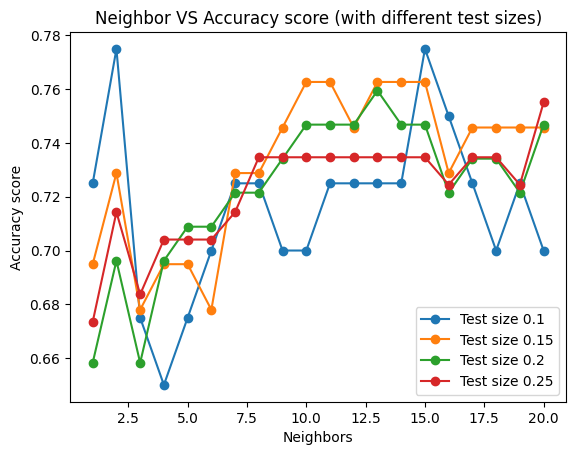

Outcome of user value : 0


c:\Users\Admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


In [10]:
df = pd.read_csv("Datasets/diabetes.csv")
print(df.head())

# handle null values
cols_with_zero = ['Glucose' , 'BloodPressure' , 'SkinThickness' , 'Insulin' , 'BMI']
for col in cols_with_zero :
    df = df[ df[col] != 0 ]

# divide x & y
x = df.drop('Outcome' , axis = 1)
y = df['Outcome']

test_sizes = [0.1 , 0.15 , 0.2 , 0.25]
neighbors_values = range(1,21)
best_acc = -1
best_model = None
best_neighbor = None
best_test_size = None

result = []

for ts in test_sizes :
    for k in neighbors_values :

        X_train , X_test , y_train , y_test = train_test_split(x , y , test_size=ts , random_state=42)

        KNN = KNeighborsClassifier(n_neighbors=k)
        KNN.fit(X_train , y_train)
        y_pre = KNN.predict(X_test)

        # accuracy score
        acc = accuracy_score(y_test , y_pre)

        if acc > best_acc :
            best_acc = acc
            best_model = KNN
            best_neighbor = k
            best_test_size = ts
        
        result.append((ts , k , acc))

print("\n---- result -----\n")
print("Best accuracy :" , acc)
print("Best test size :" , best_test_size)
print("Best neighbor :" , best_neighbor)

# create dataframe of result
result_df = pd.DataFrame(result , columns=['Test size' , 'Neighbor' , 'ACC'])

# plot graph of neighbor VS accuracy
plt.figure()
for ts in test_sizes :
    subset = result_df[ result_df['Test size'] == ts ]
    plt.plot(subset['Neighbor'] , subset['ACC'] , marker='o' , label=f'Test size {ts}')
plt.xlabel("Neighbors")
plt.ylabel("Accuracy score")
plt.title("Neighbor VS Accuracy score (with different test sizes)")
plt.legend()
plt.show()


# predict user define value
user_value = [[2,120,70,20,80,25,0.5,30]]

user_pre = best_model.predict(user_value)
print("Outcome of user value :", user_pre[0])

# Decision Tree Regression

In [11]:
from sklearn.tree import DecisionTreeClassifier

## Task 9 : simple data training and prediction for decision tree regression

In [12]:
df = pd.read_csv("Datasets/diabetes.csv")
print(df.head())

# handle null values
cols_with_zero = ['Glucose' , 'BloodPressure' , 'SkinThickness' , 'Insulin' , 'BMI']
for col in cols_with_zero :
    df = df[ df[col] != 0 ]

x = df.drop('Outcome' , axis = 1)
y = df['Outcome']

X_train , X_test , y_train , y_test = train_test_split(x , y , test_size=0.2 , random_state=42)

# initailized model
tree = DecisionTreeClassifier(random_state=42 , criterion = 'entropy' )

# fit data into model
tree.fit(X_train , y_train)

# predict value
y_pre = tree.predict(X_test)

# find confusion matrix
cm = confusion_matrix(y_test , y_pre)
TN , FP , FN , TP = cm.ravel()
print("confusion matrix : " , cm )

print("\n--- direct accuracy ---\n")
print("Accuracy :" , accuracy_score(y_test , y_pre))
print("precision :" , precision_score(y_test , y_pre))
print("recall :" , recall_score(y_test , y_pre))

print("\n--- by formulas accuracy ---\n")
acc = (TN + TP) / (TN + FP + FN + TP)
precision = (TP) / (FP + TP)
recall = (TP) / (TP + FN)
specificity = (TN) / (TN + FP)
print("Accuracy :" , acc)
print("precision :" , precision)
print("recall :" , recall)
print("specificity :" , specificity)
print()

# user values
user_data = [[2,120,70,20,80,25.0,0.5,30]]
user_pre = tree.predict(user_data)
print("Outcome for user data :" , user_pre[0])

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  
confusion matrix :  [[41 11]
 [13 14]]

--- direct accuracy ---

Accuracy : 0.6962025316455697
precision : 0.56
recall : 0.5185185185185185

--- by formulas accuracy ---

Accuracy : 0.6962025316455697
precision : 0.56
recall : 0.5185185185185185
specificity : 0.7884615384615384

Outcome for user data :

c:\Users\Admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


## Task 10 : decision tree regression with different max depth

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  
Best accuracy : 0.7468354430379747
best depth : 1


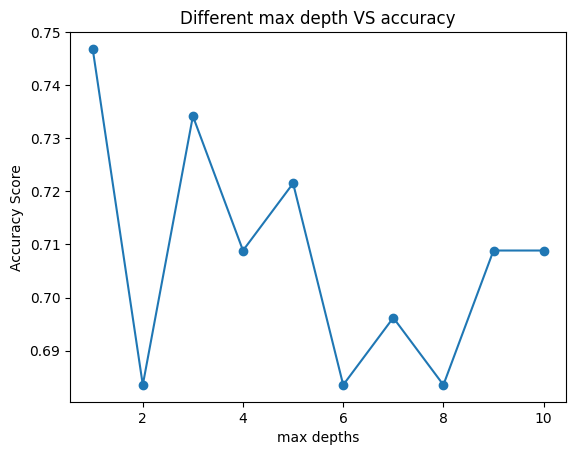

Outcome for user data : 0


c:\Users\Admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


In [13]:
df = pd.read_csv("Datasets/diabetes.csv")
print(df.head())

# handle null values
cols_with_zero = ['Glucose' , 'BloodPressure' , 'SkinThickness' , 'Insulin' , 'BMI']
for col in cols_with_zero :
    df = df[ df[col] != 0 ]

x = df.drop('Outcome' , axis = 1)
y = df['Outcome']

X_train , X_test , y_train , y_test = train_test_split(x , y , test_size=0.2 , random_state=42)

max_depths = range(1,11)
all_acc = []
best_acc = -1
best_model = None
best_depth = None

for depth in max_depths :
    tree = DecisionTreeClassifier(max_depth=depth , criterion='entropy' , random_state=42)
    tree.fit(X_train , y_train)
    y_pre = tree.predict(X_test)

    acc = accuracy_score(y_test , y_pre)

    if acc > best_acc :
        best_acc = acc
        best_model = tree
        best_depth = depth
    
    all_acc.append(acc)

# best depth & that accuracy
print("Best accuracy :" , best_acc)
print("best depth :" , best_depth)

# plot graph
plt.plot(max_depths , all_acc , marker='o')
plt.xlabel("max depths")
plt.ylabel("Accuracy Score")
plt.title("Different max depth VS accuracy")
plt.show()

# user define values
user_data = [[2,120,70,20,80,25.5,0.5,30]]
user_pre = best_model.predict(user_data)
print("Outcome for user data :" , user_pre[0])

## Task 11 : finding the best max depth for decision tree regression with best test size

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  

==== best model ====

Best Accuracy : 0.8
Best test size : 0.1
Best depth : 5


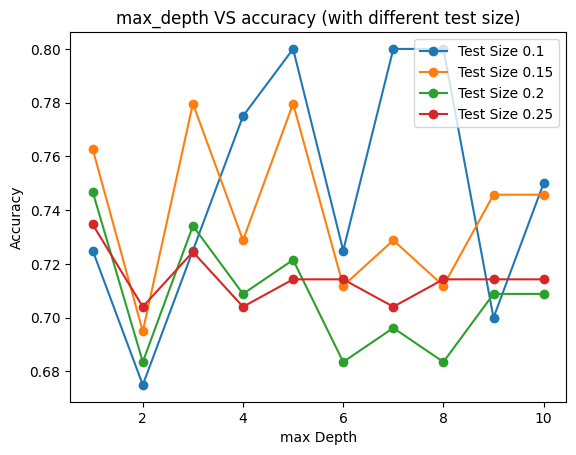

Outcome for user data : 0


c:\Users\Admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


In [14]:
df = pd.read_csv("Datasets/diabetes.csv")
print(df.head())

# handle null values
cols_with_zero = ['Glucose' , 'BloodPressure' , 'SkinThickness' , 'Insulin' , 'BMI']
for col in cols_with_zero :
    df = df[ df[col] != 0 ]

x = df.drop('Outcome' , axis = 1)
y = df['Outcome']

test_sizes = [0.1 , 0.15 , 0.2 , 0.25]
max_depths = range(1,11)
result = []
best_acc = -1
best_model = None
best_test_size = None
best_depth = None


for ts in test_sizes :
    for depth in max_depths :
        X_train , X_test , y_train , y_test = train_test_split(x , y , test_size=ts , random_state=42)

        tree = DecisionTreeClassifier(criterion='entropy' , max_depth=depth , random_state=42)
        tree.fit(X_train , y_train)
        y_pre = tree.predict(X_test)

        acc = accuracy_score(y_test , y_pre)

        if acc > best_acc :
            best_acc = acc
            best_model = tree
            best_test_size = ts
            best_depth = depth
        
        result.append((ts,depth,acc))

# print best values
print("\n==== best model ====\n")
print("Best Accuracy :" , best_acc)
print("Best test size :" , best_test_size)
print("Best depth :" , best_depth)

# create dataframe
result_df = pd.DataFrame(result , columns=['Test size' , 'Depth' , 'ACC'])

# plot graph for max_depth VS accuracy (with different test size)
plt.figure()
for ts in test_sizes :
    subset = result_df[ result_df['Test size'] == ts ]
    plt.plot(subset['Depth'] , subset['ACC'] , marker='o' , label=f"Test Size {ts}")

plt.xlabel("max Depth")
plt.ylabel("Accuracy")
plt.title("max_depth VS accuracy (with different test size)")
plt.legend()
plt.show()

# predict user data
user_data = [[2,120,70,20,80,25.5,0.5,30]]
user_pre = best_model.predict(user_data)
print("Outcome for user data :" , user_pre[0])

# random forest regression

In [15]:
from sklearn.ensemble import RandomForestClassifier

## Task 12 : simple data training and prediction for random forest regression

In [16]:
df = pd.read_csv("Datasets/diabetes.csv")
print(df.head())

# handle null values
cols_with_zero = ['Glucose' , 'BloodPressure' , 'SkinThickness' , 'Insulin' , 'BMI']
for col in cols_with_zero :
    df = df[ df[col] != 0 ]

x = df.drop('Outcome' , axis = 1)
y = df['Outcome']

X_train , X_test , y_train , y_test = train_test_split(x , y , test_size=0.2 , random_state = 42 )

# define model
forest = RandomForestClassifier(n_estimators=51 , criterion='entropy' , random_state=42)
forest.fit(X_train , y_train)

# predict values
y_pre = forest.predict(X_test)

# confusion matrix
cm = confusion_matrix(y_test , y_pre)
TN , FP , FN , TP = cm.ravel()
print("Confusion matrix :\n",cm)

# print all accurecy
print("\n--- direct accuracy ---\n")
print("Accuracy :" , accuracy_score(y_test , y_pre))
print("precision :" , precision_score(y_test , y_pre))
print("recall :" , recall_score(y_test , y_pre))

# user data prediction
user_data = [[2,120,70,20,80,25.5,0.5,30]]
user_pre = forest.predict(user_data)
print("\noutcome for user values :",user_pre[0])

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  
Confusion matrix :
 [[45  7]
 [13 14]]

--- direct accuracy ---

Accuracy : 0.7468354430379747
precision : 0.6666666666666666
recall : 0.5185185185185185

outcome for user values : 0


c:\Users\Admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


## Task 13 : finding the best n estimator for random forest regression with best test size

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


Best Accuracy : 0.8135593220338984
Best estimator : 75
Best test size : 0.15


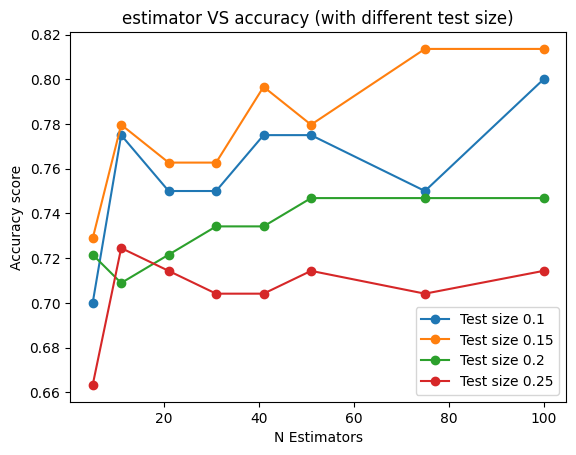

Outcome for user data : 0


c:\Users\Admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [17]:
df = pd.read_csv("Datasets/diabetes.csv")
print(df.head())

# handle null values
cols_with_zero = ['Glucose' , 'BloodPressure' , 'SkinThickness' , 'Insulin' , 'BMI']
for col in cols_with_zero :
    df = df[ df[col] != 0 ]

x = df.drop('Outcome' , axis = 1)
y = df['Outcome']

result = []

test_sizes = [0.1,0.15,0.2,0.25]
estimators = [5,11,21,31,41,51,75,100]
best_acc = 0
best_model = None
best_estimator = None
best_test_size = None

for ts in test_sizes :
    for n in estimators :
        X_train , X_test , y_train , y_test = train_test_split(x,y,test_size=ts,random_state=42)

        forest = RandomForestClassifier(n_estimators=n , criterion='entropy' , random_state=42)
        forest.fit(X_train , y_train)
        y_pre = forest.predict(X_test)

        acc = accuracy_score(y_test , y_pre)

        if acc > best_acc :
            best_acc = acc
            best_model = forest
            best_estimator = n
            best_test_size = ts
        
        result.append((ts,n,acc))
# print best model
print("Best Accuracy :" , best_acc)
print("Best estimator :" , best_estimator)
print("Best test size :" , best_test_size)

# create DataFrame for result
result_df = pd.DataFrame(result , columns=['Test size' ,'Estimator' ,'ACC'])

# design a graph estimator VS accuracy (with different test size)
for ts in test_sizes :
    subset = result_df[ result_df['Test size'] == ts ]
    plt.plot(subset['Estimator'] , subset['ACC'] , marker='o' , label=f"Test size {ts}")
plt.xlabel("N Estimators")
plt.ylabel("Accuracy score")
plt.title("estimator VS accuracy (with different test size)")
plt.legend()
plt.show()

# predict user define values
user_data = [[2,120,70,20,80,25.5,0.5,30]]
user_pre = best_model.predict(user_data)
print("Outcome for user data :" , user_pre[0])

# SVM Regression --> Support Vector Machine Regression

In [18]:
from sklearn.svm import SVC

## Task 14 : simple data training and prediction for SVM regression

In [19]:
df = pd.read_csv("Datasets/diabetes.csv")
print(df.head())

# handle null values
cols_with_zero = ['Glucose' , 'BloodPressure' , 'SkinThickness' , 'Insulin' , 'BMI']
for col in cols_with_zero :
    df = df[ df[col] != 0 ]

x = df.drop('Outcome' , axis = 1)
y = df['Outcome']  

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# define model
svc = SVC(kernel='rbf' , C=1)
svc.fit(X_train , y_train)

# predict values
y_pre = svc.predict(X_test)

# confusion matrix
cm = confusion_matrix(y_test , y_pre)
TN , FP , FN , TP = cm.ravel()
print("Confusion matrix :\n" , cm)

# all accuracies
print("Accuracy : " ,accuracy_score(y_test , y_pre))
print("precision : " ,precision_score(y_test , y_pre))
print("recall : " ,recall_score(y_test , y_pre))

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  
Confusion matrix :
 [[48  4]
 [16 11]]
Accuracy :  0.7468354430379747
precision :  0.7333333333333333


recall :  0.4074074074074074


## Task 15 : finding best C value for SVM regression

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  

--- best ---

Best acc : 0.759493670886076
Best c value : 50


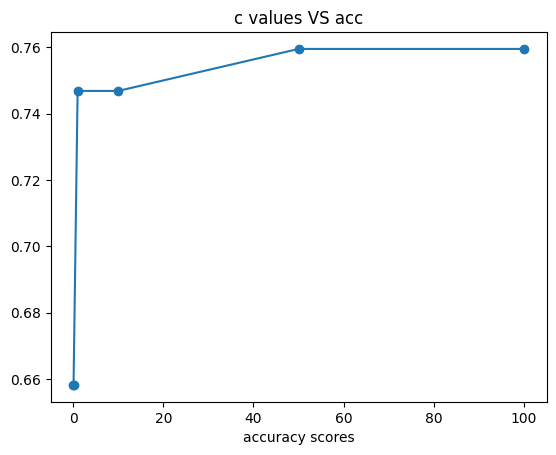

In [20]:
df = pd.read_csv("Datasets/diabetes.csv")
print(df.head())

# handle null values
cols_with_zero = ['Glucose' , 'BloodPressure' , 'SkinThickness' , 'Insulin' , 'BMI']
for col in cols_with_zero :
    df = df[ df[col] != 0 ]

x = df.drop('Outcome' , axis = 1)
y = df['Outcome']  

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

c_val = [0.01 , 0.1 , 1 , 10 , 50 , 100]
all_acc = []
best_acc = -1
best_c_val = None
best_model = None

for c in c_val :
    svc = SVC(C=c , kernel='rbf')
    svc.fit(X_train , y_train)
    y_pre = svc.predict(X_test)

    acc = accuracy_score(y_test , y_pre)

    if acc > best_acc :
        best_acc = acc
        best_c_val = c
        best_model = svc
    
    all_acc.append(acc)

# print best model
print("\n--- best ---\n")
print("Best acc :" , best_acc)
print("Best c value :" , best_c_val)

# plot graph c values VS acc
plt.plot(c_val , all_acc , marker='o')
plt.xlabel("c values")
plt.xlabel("accuracy scores")
plt.title("c values VS acc")
plt.show()

## Task 16 : finding best kernel for SVM regression with best C value and best test size

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  

--- best ---

Best acc : 0.7796610169491526
Best c value : 100
Best test size : 0.15


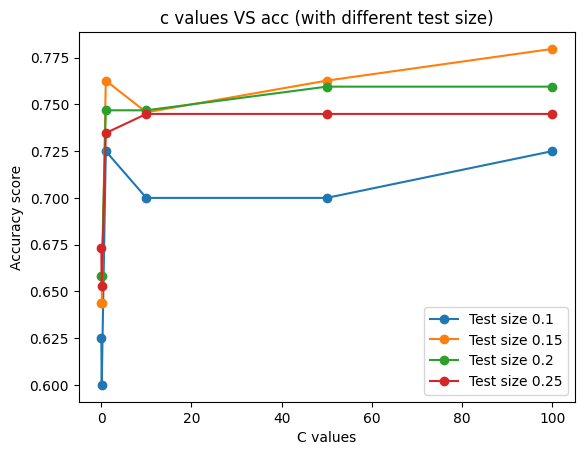

In [21]:
df = pd.read_csv("Datasets/diabetes.csv")
print(df.head())

# handle null values
cols_with_zero = ['Glucose' , 'BloodPressure' , 'SkinThickness' , 'Insulin' , 'BMI']
for col in cols_with_zero :
    df = df[ df[col] != 0 ]

x = df.drop('Outcome' , axis = 1)
y = df['Outcome']  


c_val = [0.01 , 0.1 , 1 , 10 , 50 , 100]
test_sizes = [0.1 , 0.15 , 0.2 ,0.25]
result = []
best_acc = -1
best_c_val = None
best_test_size = None
best_model = None

for ts in test_sizes :
    for c in c_val :
        X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=ts, random_state=42)
        
        svc = SVC(C=c , kernel='rbf')
        svc.fit(X_train , y_train)
        y_pre = svc.predict(X_test)

        acc = accuracy_score(y_test , y_pre)

        if acc > best_acc :
            best_acc = acc
            best_c_val = c
            best_model = svc
            best_test_size = ts
        
        result.append((ts,c,acc))

# print best model
print("\n--- best ---\n")
print("Best acc :" , best_acc)
print("Best c value :" , best_c_val)
print("Best test size :" , best_test_size)

# create dataframe
result_df = pd.DataFrame(result , columns=['Test size' , 'C' , 'ACC'])

# plot graph of c values VS acc (with different test size)
for ts in test_sizes :
    subset = result_df[ result_df['Test size'] == ts ]
    plt.plot(subset['C'] , subset['ACC'] , marker='o' , label=f'Test size {ts}')

plt.xlabel("C values")
plt.ylabel("Accuracy score")
plt.title("c values VS acc (with different test size)")
plt.legend()
plt.show()


# Task 17

In [ ]:
df = pd.read_csv("Datasets/Employee_Attrition.csv")
print(df.head(2))

df = df.drop("Employee_ID" , axis=1)

x = df.drop('Attrition' , axis=1)
y = df['Attrition']

x = pd.get_dummies(x,drop_first=True)

# KNN
X_train , X_test , y_train , y_test = train_test_split(x , y , test_size=0.2 , random_state=42)

k_vals = range(1,26)
best_k = None
best_r2 = 0
best_model = None

for k in k_vals :
    KNN = KNeighborsClassifier(n_neighbors = k)
    KNN.fit(X_train , y_train)
    y_pre = KNN.predict(X_test)

    acc = accuracy_score(y_test , y_pre)

    if acc > best_acc :
        best_k = k
        best_r2 = acc
        best_model = KNN

print("\n--- best model ---\n")
print("Best accuracy : " , best_acc)
print("Best K value : " , best_k)


# Random forest

forest = RandomForestClassifier(n_estimators=150 ,max_depth=12)
forest.fit(X_train , y_train)
y_pre_forest = forest.predict(X_test)

acc_forest = accuracy_score(y_test , y_pre_forest)
print("Accuracy for random forest :" , acc_forest)
cm = confusion_matrix(y_test,y_pre_forest)
print("Confusion matrix for random forest :\n" , cm)


print(X_train.columns)
# prediction
data = [[30,45000,5,3,10,1,0,0,1,0,1,0,0]]

pre_knn = best_model.predict(data)
pre_forest = forest.predict(data)

print("Prediction by KNN --> " , pre_knn[0])
print("Prediction by random forest --> " , pre_forest[0])

   Employee_ID  Age  Monthly_Income  Years_at_Company Job_Role  \
0            1   29           23278                 8  Manager   
1            2   56           31395                18       HR   

  Work_Life_Balance Overtime  Job_Satisfaction  Distance_From_Home  \
0              Poor      Yes                 1                  22   
1              Poor      Yes                 1                   7   

      Education  Attrition  
0  Postgraduate          1  
1        School          1  

--- best model ---

Best accuracy :  0.7796610169491526
Best K value :  25
Accuracy for random forest : 1.0
Confusion matrix for random forest :
 [[47  0]
 [ 0  3]]
Index(['Age', 'Monthly_Income', 'Years_at_Company', 'Job_Satisfaction',
       'Distance_From_Home', 'Job_Role_Developer', 'Job_Role_HR',
       'Job_Role_Manager', 'Work_Life_Balance_Good', 'Work_Life_Balance_Poor',
       'Overtime_Yes', 'Education_Postgraduate', 'Education_School'],
      dtype='object')
Prediction by KNN -->  0
Pre

c:\Users\Admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(
c:\Users\Admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


# Task 17 : finding the best regression model for the given data with best test size

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  

 ---- best model ----

model name :  forest
best accuracy :  0.7796610169491526
best test size :  0.15



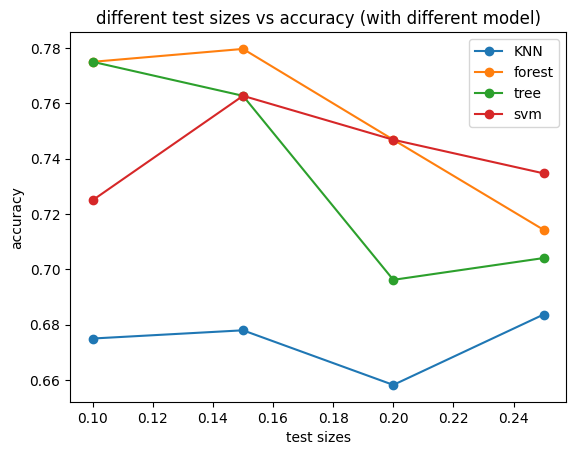

prediction for new data :  0


c:\Users\Admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [33]:
df = pd.read_csv("Datasets/diabetes.csv")
print(df.head())

# handle null values
cols_with_zero = ['Glucose' , 'BloodPressure' , 'SkinThickness' , 'Insulin' , 'BMI']
for col in cols_with_zero :
    df = df[ df[col] != 0 ]

x = df.drop('Outcome' , axis = 1)
y = df['Outcome']  

test_sizes = [0.1 , 0.15 , 0.2 , 0.25]
result = {
    "KNN" : [] ,
    "forest" : [] ,
    "tree" : [],
    "svm" : []
}

best_acc = 0
best_test_size = None
best_model = None
best_model_name = None

for ts in test_sizes :
    X_train , X_test , y_train , y_test = train_test_split(x , y , test_size=ts , random_state=42)

    models = {
        "KNN" : KNeighborsClassifier(n_neighbors=3),
        "tree" : DecisionTreeClassifier(criterion='entropy' , random_state=42),
        "forest" : RandomForestClassifier(criterion='entropy' , random_state=42 , n_estimators=51),
        "svm" : SVC(C=1 , kernel='rbf' , random_state=42)
    }
    for name , model in models.items() :
        model.fit(X_train , y_train)
        y_pre = model.predict(X_test)
        acc = accuracy_score(y_test , y_pre)

        if acc > best_acc :
            best_acc = acc
            best_test_size = ts
            best_model = model
            best_model_name = name
        
        result[name].append(acc)

print("\n ---- best model ----\n")
print("model name : " , best_model_name)
print("best accuracy : " , best_acc)
print("best test size : " , best_test_size)
print()

# plot
for name , val in result.items() :
    plt.plot(test_sizes , val , marker='o' , label=name)
plt.xlabel("test sizes")
plt.ylabel("accuracy")
plt.title("different test sizes vs accuracy (with different model)")
plt.legend()
plt.show()


# prediction
new_data = [[2, 120, 70, 20, 80, 25.0, 0.5, 30]]
data_pre = best_model.predict(new_data)
print("prediction for new data : " , data_pre[0])